# GNN Auditing: Robustness to Topological and Feature Noise

How robust are GNN predictions and anomaly rankings when structural topology or node attributes are noisy? In this notebook, we audit GCN and GraphSAGE on **Cora** by applying three types of synthetic noise across sweeping intensities:
1. **Edge Deletion**: Randomly removing a fraction of edges ($p \in [0, 0.05, 0.1, 0.2, 0.4]$).
2. **Edge Addition**: Randomly adding a fraction of spurious edges.
3. **Feature Gaussian Noise**: Injecting additive Gaussian noise $\epsilon \sim \mathcal{N}(0, \sigma^2 \mathbf{I})$ to the continuous input features ($y \in [0, 0.1, 0.2, 0.5, 1.0]$).

We evaluate how quickly model validation accuracy degrades and how stable the Isolation Forest anomaly rankings remain (using **Spearman Rank Correlation** against the baseline anomaly ranking).

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.ensemble import IsolationForest

from main import load_dataset, build_model, set_seed
from train import train_one_epoch
from test import evaluate
from parameters import ModelParams, TrainParams, DataParams

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Setup complete. Device:', DEVICE)

Setup complete. Device: cuda


## Helpers for Adding Synthetic Perturbations

In [2]:
def perturb_edges_delete(edge_index, p):
    """Randomly delete a fraction p of edges (maintaining undirected integrity)."""
    if p == 0.0: return edge_index
    num_edges = edge_index.size(1)
    keep_mask = torch.rand(num_edges) > p
    return edge_index[:, keep_mask]

def perturb_edges_add(edge_index, num_nodes, p):
    """Randomly add a fraction p of spurious edges."""
    if p == 0.0: return edge_index
    num_edges = edge_index.size(1)
    num_to_add = int(num_edges * p)
    
    new_edges = torch.randint(0, num_nodes, (2, num_to_add), device=edge_index.device)
    return torch.cat([edge_index, new_edges], dim=1)

def perturb_features_noise(x, std):
    """Add zero-mean Gaussian noise to feature matrix."""
    if std == 0.0: return x
    noise = torch.randn_like(x) * std
    return x + noise

## Robustness Experiment Pipeline

In [3]:
def run_robustness_experiment(model_name, pert_type, pert_values, epochs=80):
    set_seed(42)
    
    data_params = DataParams(dataset_name='cora', seed=42)
    ds_info = load_dataset(data_params)
    clean_data = ds_info['data'].to(DEVICE)
    train_mask = ds_info['train_mask'].to(DEVICE)
    test_mask = ds_info['test_mask'].to(DEVICE)
    
    # Get baseline embeddings & anomalies on clean data
    model_params = ModelParams(model_name=model_name, hidden_channels=64, num_layers=2, dropout=0.5)
    baseline_model = build_model(model_params, ds_info['num_features'], ds_info['num_classes'], 'node').to(DEVICE)
    optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.01, weight_decay=5e-4)
    
    # Train baseline
    for _ in range(epochs):
        baseline_model.train()
        optimizer.zero_grad()
        out = baseline_model(clean_data.x, clean_data.edge_index)
        loss = F.nll_loss(out[train_mask], clean_data.y[train_mask])
        loss.backward()
        optimizer.step()
        
    baseline_model.eval()
    with torch.no_grad():
        clean_emb = baseline_model.embed(clean_data.x, clean_data.edge_index).cpu().numpy()
        
    iso_clean = IsolationForest(contamination=0.1, random_state=42)
    iso_clean.fit(clean_emb)
    clean_anom_ranks = np.argsort(-iso_clean.score_samples(clean_emb))
    
    accuracies = []
    anomaly_corrs = []
    
    for val in pert_values:
        print(f'Sweeping {pert_type} = {val:.2f}...')
        
        # Perturb graph data
        p_x = clean_data.x.clone()
        p_edge = clean_data.edge_index.clone()
        
        if pert_type == 'edge_drop':
            p_edge = perturb_edges_delete(p_edge, val)
        elif pert_type == 'edge_add':
            p_edge = perturb_edges_add(p_edge, clean_data.num_nodes, val)
        elif pert_type == 'feature_noise':
            p_x = perturb_features_noise(p_x, val)
            
        # Retrain model on perturbed data
        model = build_model(model_params, ds_info['num_features'], ds_info['num_classes'], 'node').to(DEVICE)
        opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
        
        for _ in range(epochs):
            model.train()
            opt.zero_grad()
            out = model(p_x, p_edge)
            loss = F.nll_loss(out[train_mask], clean_data.y[train_mask])
            loss.backward()
            opt.step()
            
        # Evaluate perturbed performance
        model.eval()
        with torch.no_grad():
            pred_out = model(p_x, p_edge)
            pred = pred_out.argmax(dim=-1)
            acc = (pred[test_mask] == clean_data.y[test_mask]).sum().item() / test_mask.sum().item()
            
            pert_emb = model.embed(p_x, p_edge).cpu().numpy()
            
        # Anomaly stability rank correlation
        iso_pert = IsolationForest(contamination=0.1, random_state=42)
        iso_pert.fit(pert_emb)
        pert_anom_ranks = np.argsort(-iso_pert.score_samples(pert_emb))
        
        # Calculate Spearman correlation
        corr, _ = spearmanr(clean_anom_ranks, pert_anom_ranks)
        
        accuracies.append(acc)
        anomaly_corrs.append(corr)
        
    return pd.DataFrame({
        'perturb_value': pert_values,
        'accuracy': accuracies,
        'anomaly_correlation': anomaly_corrs
    })

## Run Robustness Sweeps

In [4]:
EDGE_SWEEP = [0.0, 0.05, 0.1, 0.2, 0.4]
FEAT_SWEEP = [0.0, 0.1, 0.2, 0.5, 1.0]

print('--- Sweeping GCN edge dropping ---')
df_gcn_drop = run_robustness_experiment('gcn', 'edge_drop', EDGE_SWEEP)

print('\n--- Sweeping GCN edge addition ---')
df_gcn_add = run_robustness_experiment('gcn', 'edge_add', EDGE_SWEEP)

print('\n--- Sweeping GCN feature noise ---')
df_gcn_feat = run_robustness_experiment('gcn', 'feature_noise', FEAT_SWEEP)

print('\n--- Sweeping GraphSAGE edge dropping ---')
df_sage_drop = run_robustness_experiment('graphsage', 'edge_drop', EDGE_SWEEP)

print('\n--- Sweeping GraphSAGE edge addition ---')
df_sage_add = run_robustness_experiment('graphsage', 'edge_add', EDGE_SWEEP)

print('\n--- Sweeping GraphSAGE feature noise ---')
df_sage_feat = run_robustness_experiment('graphsage', 'feature_noise', FEAT_SWEEP)

--- Sweeping GCN edge dropping ---


Sweeping edge_drop = 0.00...


Sweeping edge_drop = 0.05...


Sweeping edge_drop = 0.10...


Sweeping edge_drop = 0.20...


...

Sweeping feature_noise = 0.00...


Sweeping feature_noise = 0.10...


Sweeping feature_noise = 0.20...


Sweeping feature_noise = 0.50...


Sweeping feature_noise = 1.00...


## Plotting Perturbation Auditing Results

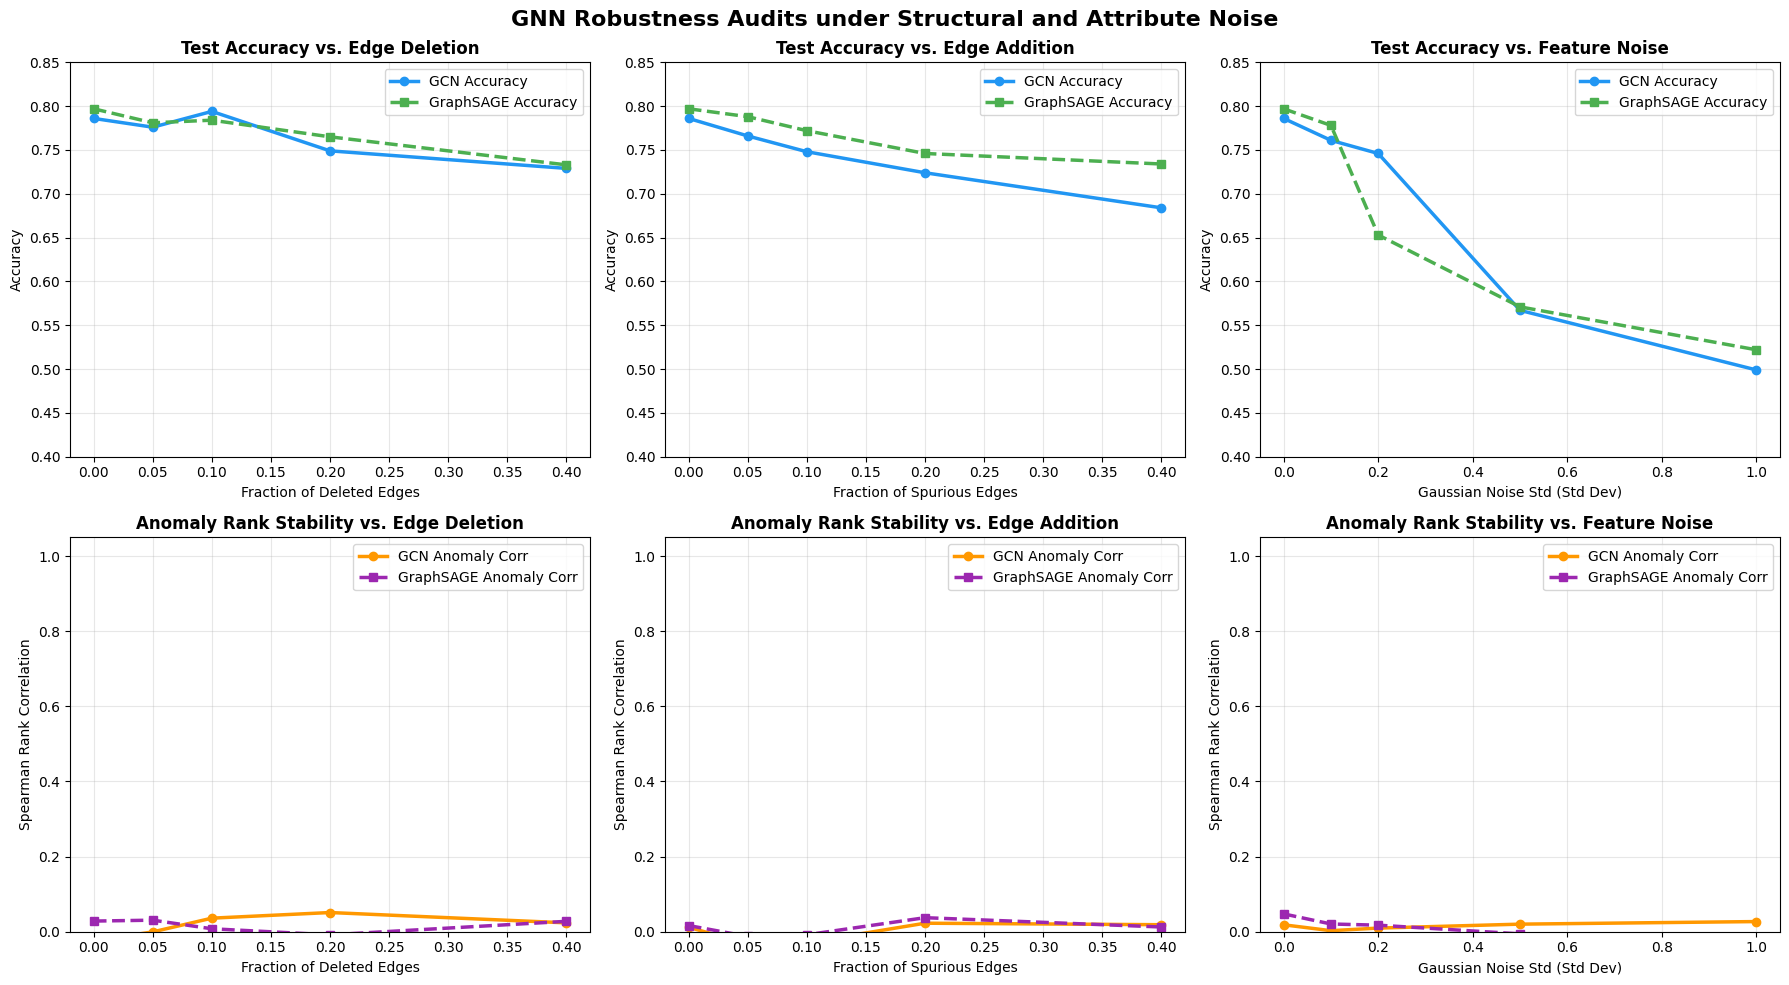

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ---------------- EDGE DROPPING ----------------
# Accuracy
ax = axes[0, 0]
ax.plot(EDGE_SWEEP, df_gcn_drop['accuracy'], 'o-', linewidth=2.5, color='#2196F3', label='GCN Accuracy')
ax.plot(EDGE_SWEEP, df_sage_drop['accuracy'], 's--', linewidth=2.5, color='#4CAF50', label='GraphSAGE Accuracy')
ax.set_title('Test Accuracy vs. Edge Deletion', fontweight='bold')
ax.set_xlabel('Fraction of Deleted Edges')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0.4, 0.85)

# Anomaly rank correlation
ax = axes[1, 0]
ax.plot(EDGE_SWEEP, df_gcn_drop['anomaly_correlation'], 'o-', linewidth=2.5, color='#FF9800', label='GCN Anomaly Corr')
ax.plot(EDGE_SWEEP, df_sage_drop['anomaly_correlation'], 's--', linewidth=2.5, color='#9C27B0', label='GraphSAGE Anomaly Corr')
ax.set_title('Anomaly Rank Stability vs. Edge Deletion', fontweight='bold')
ax.set_xlabel('Fraction of Deleted Edges')
ax.set_ylabel('Spearman Rank Correlation')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0.0, 1.05)

# ---------------- EDGE ADDITION ----------------
# Accuracy
ax = axes[0, 1]
ax.plot(EDGE_SWEEP, df_gcn_add['accuracy'], 'o-', linewidth=2.5, color='#2196F3', label='GCN Accuracy')
ax.plot(EDGE_SWEEP, df_sage_add['accuracy'], 's--', linewidth=2.5, color='#4CAF50', label='GraphSAGE Accuracy')
ax.set_title('Test Accuracy vs. Edge Addition', fontweight='bold')
ax.set_xlabel('Fraction of Spurious Edges')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0.4, 0.85)

# Anomaly rank correlation
ax = axes[1, 1]
ax.plot(EDGE_SWEEP, df_gcn_add['anomaly_correlation'], 'o-', linewidth=2.5, color='#FF9800', label='GCN Anomaly Corr')
ax.plot(EDGE_SWEEP, df_sage_add['anomaly_correlation'], 's--', linewidth=2.5, color='#9C27B0', label='GraphSAGE Anomaly Corr')
ax.set_title('Anomaly Rank Stability vs. Edge Addition', fontweight='bold')
ax.set_xlabel('Fraction of Spurious Edges')
ax.set_ylabel('Spearman Rank Correlation')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0.0, 1.05)

# ---------------- FEATURE NOISE ----------------
# Accuracy
ax = axes[0, 2]
ax.plot(FEAT_SWEEP, df_gcn_feat['accuracy'], 'o-', linewidth=2.5, color='#2196F3', label='GCN Accuracy')
ax.plot(FEAT_SWEEP, df_sage_feat['accuracy'], 's--', linewidth=2.5, color='#4CAF50', label='GraphSAGE Accuracy')
ax.set_title('Test Accuracy vs. Feature Noise', fontweight='bold')
ax.set_xlabel('Gaussian Noise Std (Std Dev)')
ax.set_ylabel('Accuracy')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0.4, 0.85)

# Anomaly rank correlation
ax = axes[1, 2]
ax.plot(FEAT_SWEEP, df_gcn_feat['anomaly_correlation'], 'o-', linewidth=2.5, color='#FF9800', label='GCN Anomaly Corr')
ax.plot(FEAT_SWEEP, df_sage_feat['anomaly_correlation'], 's--', linewidth=2.5, color='#9C27B0', label='GraphSAGE Anomaly Corr')
ax.set_title('Anomaly Rank Stability vs. Feature Noise', fontweight='bold')
ax.set_xlabel('Gaussian Noise Std (Std Dev)')
ax.set_ylabel('Spearman Rank Correlation')
ax.grid(True, alpha=0.3)
ax.legend()
ax.set_ylim(0.0, 1.05)

plt.suptitle('GNN Robustness Audits under Structural and Attribute Noise', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('robustness_noise_analysis.png', dpi=120, bbox_inches='tight')
plt.show()